In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('netflix_titles.csv')

print(f"Dataset Dimensions: {df.shape}")
df.head()

Dataset Dimensions: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Check the total number of missing values in each column
missing_data = df.isnull().sum()
print("--- Missing Values Per Column ---")
print(missing_data[missing_data > 0])

# Calculate the percentage of missing data for context
print("\n--- Percentage of Missing Data ---")
print((df.isnull().sum() / len(df)) * 100)

--- Missing Values Per Column ---
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

--- Percentage of Missing Data ---
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [4]:
# 1. Fill missing values in large categorical columns with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Check how many missing values remain in these specific columns
print("Missing directors:", df['director'].isnull().sum())
print("Missing cast:", df['cast'].isnull().sum())
print("Missing country:", df['country'].isnull().sum())

Missing directors: 0
Missing cast: 0
Missing country: 0


In [5]:
# 2. Drop the rows with missing critical structural data
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# Verify that no missing values remain in the entire dataset
print("Remaining missing values in dataset:", df.isnull().sum().sum())
print("Current dataset dimensions:", df.shape)


Remaining missing values in dataset: 0
Current dataset dimensions: (8790, 12)


In [6]:
# 3. Clean 'date_added' by stripping extra spaces and converting to datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Verify the column type has changed to datetime64
print("Data type of 'date_added':", df['date_added'].dtype)
# Show a quick peek at the updated dates
print("\nFirst few rows of date_added:")
print(df['date_added'].head())


Data type of 'date_added': datetime64[ns]

First few rows of date_added:
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [7]:
# 4. Extract calendar features for easier future analysis
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Verify the new columns have been added properly
print("New columns check:")
print(df[['date_added', 'year_added', 'month_added']].head())

New columns check:
  date_added  year_added month_added
0 2021-09-25        2021   September
1 2021-09-24        2021   September
2 2021-09-24        2021   September
3 2021-09-24        2021   September
4 2021-09-24        2021   September


In [8]:
# Count the frequency of each content type
type_counts = df['type'].value_counts()
type_percentages = df['type'].value_counts(normalize=True) * 100

# Display the summary breakdown
print("--- Content Type Breakdown ---")
for category in type_counts.index:
    print(f"{category}: {type_counts[category]} items ({type_percentages[category]:.2f}%)")

--- Content Type Breakdown ---
Movie: 6126 items (69.69%)
TV Show: 2664 items (30.31%)


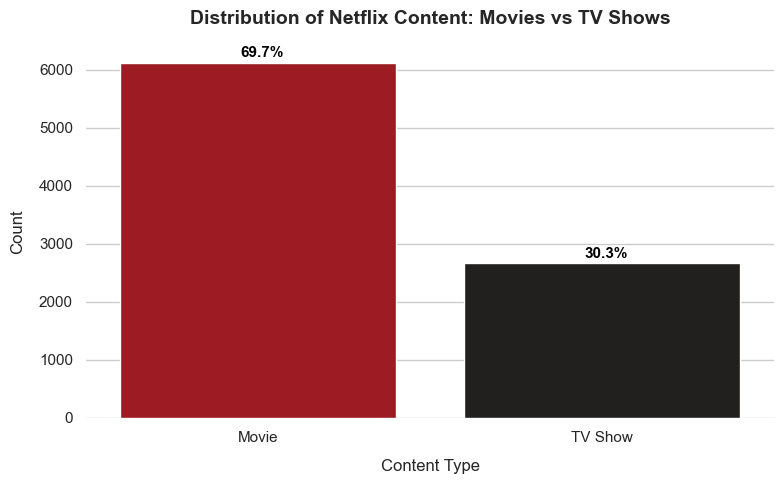

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Define colors for the breakdown
colors = ['#b20710', '#221f1f']  # Netflix red and dark charcoal

# Create the bar plot
ax = sns.barplot(
    x=type_counts.index, 
    y=type_counts.values, 
    palette=colors, 
    hue=type_counts.index, 
    legend=False
)

# Add titles and labels with custom fontsizes
plt.title('Distribution of Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Content Type', fontsize=12, labelpad=10)
plt.ylabel('Count', fontsize=12, labelpad=10)

# Add percentage annotations on top of each bar
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 100
    ax.annotate(percentage, (x, y), fontsize=11, fontweight='bold', color='black')

# Clean up the top and right spines for a modern look
sns.despine(left=True, bottom=True)

# Display the plot
plt.tight_layout()
plt.show()

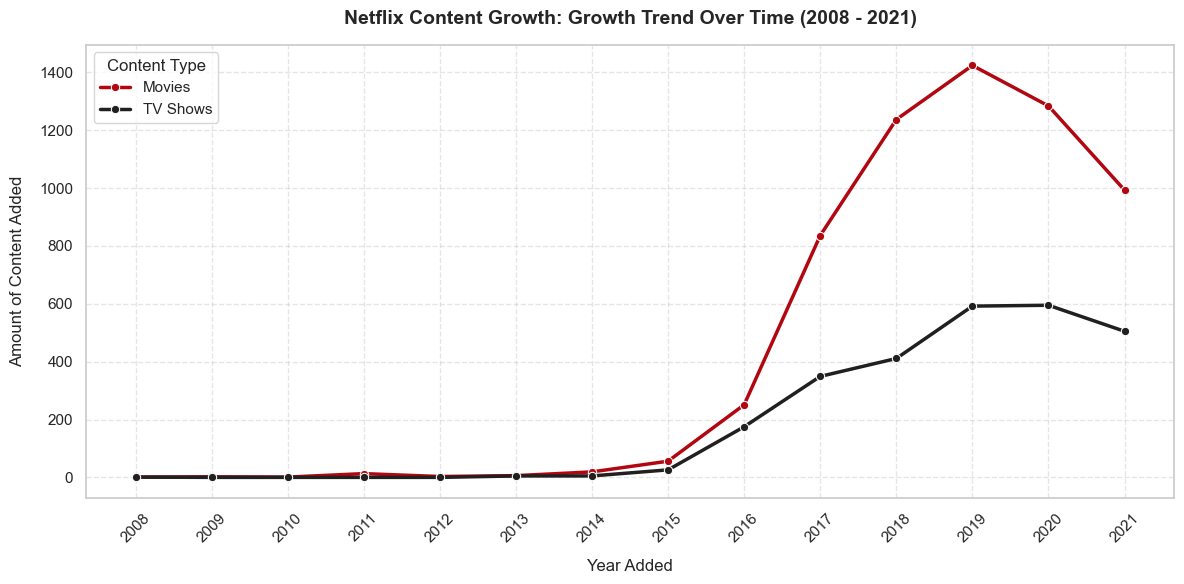

In [10]:
# Group by year added and content type, then count the releases
content_by_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Filter out the current year if it's incomplete, or just plot the trends
# We will look at data up to the most recent complete years (e.g., 2008 to 2021)
content_by_year_filtered = content_by_year.loc[2008:2021]

# Set up the plot layout
plt.figure(figsize=(12, 6))

# Plot line charts for both types
sns.lineplot(data=content_by_year_filtered, x=content_by_year_filtered.index, y='Movie', 
             color='#b20710', marker='o', linewidth=2.5, label='Movies')
sns.lineplot(data=content_by_year_filtered, x=content_by_year_filtered.index, y='TV Show', 
             color='#221f1f', marker='o', linewidth=2.5, label='TV Shows')

# Titles and labels
plt.title('Netflix Content Growth: Growth Trend Over Time (2008 - 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added', fontsize=12, labelpad=10)
plt.ylabel('Amount of Content Added', fontsize=12, labelpad=10)
plt.xticks(content_by_year_filtered.index, rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.legend(title='Content Type', frameon=True)

# Clean up layout margins
plt.tight_layout()
plt.show()

In [11]:
# Split multi-country listings and explode them into individual rows
countries_exploded = df['country'].str.split(', ').explode()

# Count the occurrences of each country (excluding 'Unknown')
top_countries = countries_exploded[countries_exploded != 'Unknown'].value_counts().head(10)

# Display the numerical results
print("--- Top 10 Content Producing Countries on Netflix ---")
for idx, (country, count) in enumerate(top_countries.items(), 1):
    print(f"{idx}. {country}: {count} titles")

--- Top 10 Content Producing Countries on Netflix ---
1. United States: 3680 titles
2. India: 1046 titles
3. United Kingdom: 803 titles
4. Canada: 445 titles
5. France: 393 titles
6. Japan: 316 titles
7. Spain: 232 titles
8. South Korea: 231 titles
9. Germany: 226 titles
10. Mexico: 169 titles


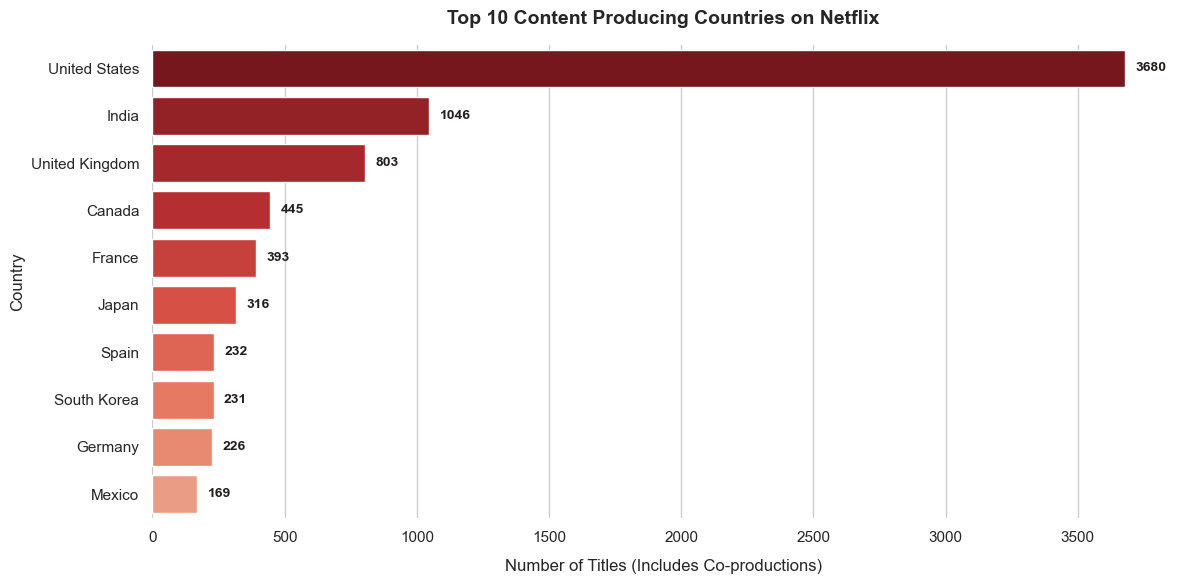

In [12]:
plt.figure(figsize=(12, 6))

# Custom palette fading from Netflix red down to dark charcoal
country_palette = sns.color_palette("Reds_r", n_colors=15)[:10]

# Create horizontal bar plot
ax = sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    palette=country_palette,
    hue=top_countries.index,
    legend=False
)

# Titles and labels
plt.title('Top 10 Content Producing Countries on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles (Includes Co-productions)', fontsize=12, labelpad=10)
plt.ylabel('Country', fontsize=12)

# Add value labels on the right side of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width + 40, p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, fontweight='bold', color='#221f1f')

# Clean up borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [13]:
# Count the frequencies of each age rating
top_ratings = df['rating'].value_counts().head(5)

# Display the numerical results
print("--- Top 5 Content Ratings on Netflix ---")
for idx, (rating, count) in enumerate(top_ratings.items(), 1):
    print(f"{idx}. {rating}: {count} titles")
    

--- Top 5 Content Ratings on Netflix ---
1. TV-MA: 3205 titles
2. TV-14: 2157 titles
3. TV-PG: 861 titles
4. R: 799 titles
5. PG-13: 490 titles


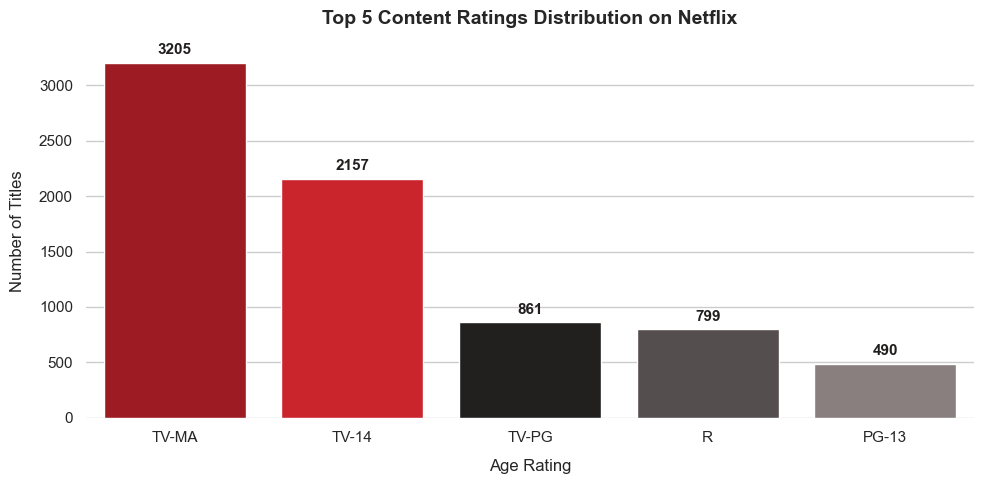

In [15]:
plt.figure(figsize=(10, 5))

# Using a distinct red-to-dark gradient for the top 5 bars
rating_colors = ['#b20710', '#e50914', '#221f1f', '#564d4d', '#8c7d7d']

# Create a clean vertical bar plot
ax = sns.barplot(
    x=top_ratings.index, 
    y=top_ratings.values, 
    palette=rating_colors,
    hue=top_ratings.index,
    legend=False
)

# Titles and labels
plt.title('Top 5 Content Ratings Distribution on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Rating', fontsize=12, labelpad=10)
plt.ylabel('Number of Titles', fontsize=12, labelpad=10)

# Add exact value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height + 50),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#221f1f')

# Clean up the chart borders for a sleek look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [16]:
# Split genres listed together and explode them into individual rows
genres_exploded = df['listed_in'].str.split(', ').explode()

# Get the count for the top 10 genres
top_genres = genres_exploded.value_counts().head(10)

# Display the numerical results
print("--- Top 10 Genres on Netflix ---")
for idx, (genre, count) in enumerate(top_genres.items(), 1):
    print(f"{idx}. {genre}: {count} titles")

--- Top 10 Genres on Netflix ---
1. International Movies: 2752 titles
2. Dramas: 2426 titles
3. Comedies: 1674 titles
4. International TV Shows: 1349 titles
5. Documentaries: 869 titles
6. Action & Adventure: 859 titles
7. TV Dramas: 762 titles
8. Independent Movies: 756 titles
9. Children & Family Movies: 641 titles
10. Romantic Movies: 616 titles


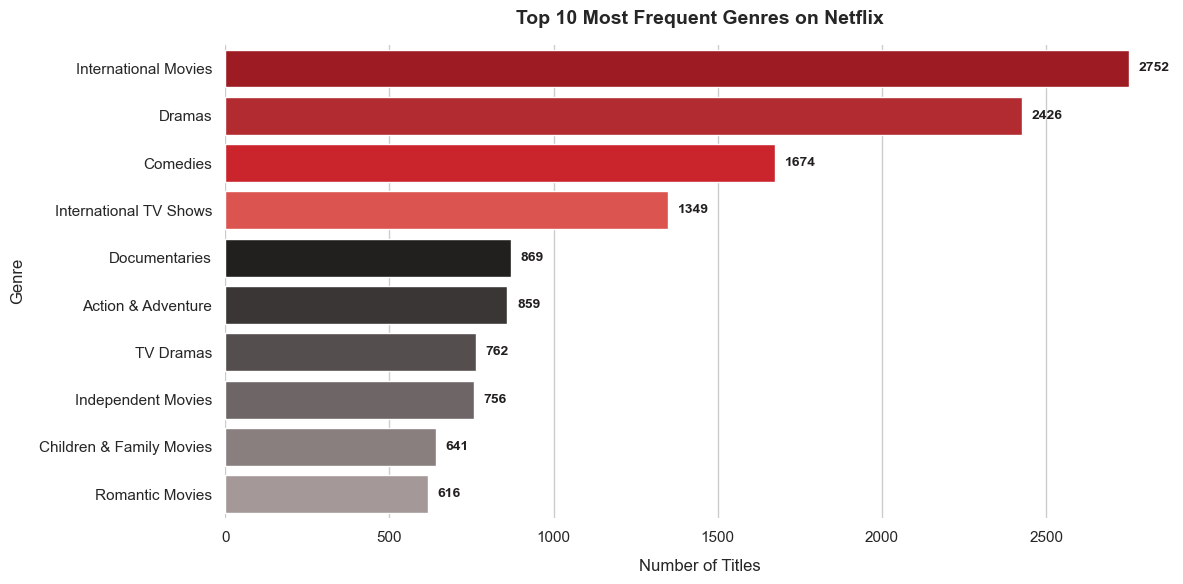

In [17]:
plt.figure(figsize=(12, 6))

# Define an expansive red-to-gray gradient palette for the 10 bars
genre_colors = [
    '#b20710', '#c9141b', '#e50914', '#f43e37', '#221f1f', 
    '#3c3535', '#564d4d', '#706464', '#8c7d7d', '#a69696'
]

# Create the horizontal bar plot
ax = sns.barplot(
    x=top_genres.values, 
    y=top_genres.index, 
    palette=genre_colors,
    hue=top_genres.index,
    legend=False
)

# Titles and labels
plt.title('Top 10 Most Frequent Genres on Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontsize=12, labelpad=10)
plt.ylabel('Genre', fontsize=12, labelpad=10)

# Add exact value labels on the right side of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width + 30, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#221f1f')

# Clean up chart borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [18]:
# Separate the dataset into Movies and TV Shows
movies_df = df[df['type'] == 'Movie']
tv_shows_df = df[df['type'] == 'TV Show']

# Find the top 5 most frequent durations for each type
top_movie_durations = movies_df['duration'].value_counts().head(5)
top_tv_durations = tv_shows_df['duration'].value_counts().head(5)

# Display numerical results
print("--- Top 5 Most Common Movie Lengths ---")
for idx, (duration, count) in enumerate(top_movie_durations.items(), 1):
    print(f"{idx}. {duration}: {count} movies")

print("\n--- Top 5 Most Common TV Show Lengths ---")
for idx, (duration, count) in enumerate(top_tv_durations.items(), 1):
    print(f"{idx}. {duration}: {count} shows")

--- Top 5 Most Common Movie Lengths ---
1. 90 min: 152 movies
2. 94 min: 146 movies
3. 93 min: 146 movies
4. 97 min: 146 movies
5. 91 min: 144 movies

--- Top 5 Most Common TV Show Lengths ---
1. 1 Season: 1791 shows
2. 2 Seasons: 421 shows
3. 3 Seasons: 198 shows
4. 4 Seasons: 94 shows
5. 5 Seasons: 64 shows


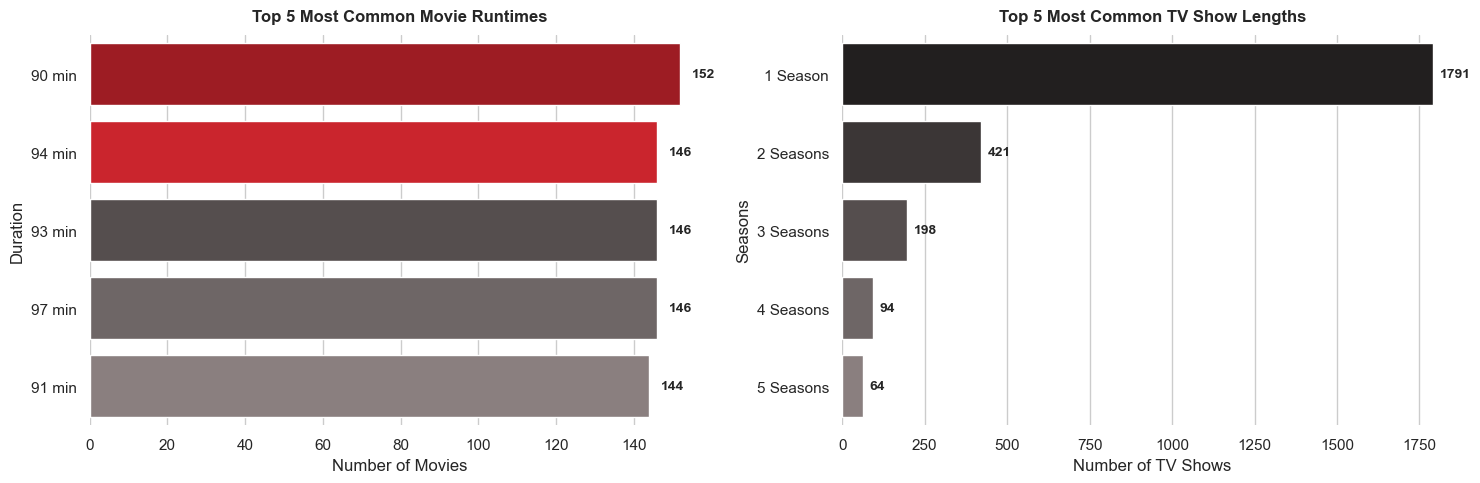

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Top Movie Lengths
sns.barplot(
    x=top_movie_durations.values, 
    y=top_movie_durations.index, 
    ax=axes[0], 
    palette=['#b20710', '#e50914', '#564d4d', '#706464', '#8c7d7d'],
    hue=top_movie_durations.index,
    legend=False
)
axes[0].set_title('Top 5 Most Common Movie Runtimes', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Movies')
axes[0].set_ylabel('Duration')

# Add values to movie bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}', (p.get_width() + 3, p.get_y() + p.get_height()/2), 
                    ha='left', va='center', fontsize=10, fontweight='bold')

# Subplot 2: Top TV Show Lengths
sns.barplot(
    x=top_tv_durations.values, 
    y=top_tv_durations.index, 
    ax=axes[1], 
    palette=['#221f1f', '#3c3535', '#564d4d', '#706464', '#8c7d7d'],
    hue=top_tv_durations.index,
    legend=False
)
axes[1].set_title('Top 5 Most Common TV Show Lengths', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Number of TV Shows')
axes[1].set_ylabel('Seasons')

# Add values to TV show bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', (p.get_width() + 20, p.get_y() + p.get_height()/2), 
                    ha='left', va='center', fontsize=10, fontweight='bold')

# Clean up layout and borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [20]:
# Filter specifically for content where India is listed as a country
india_df = df[df['country'].str.contains('India', na=False)]

# Split and explode directors to accurately count individuals
india_directors = india_df['director'].dropna().str.split(', ').explode()

# Get the top 5 most frequent directors
top_india_directors = india_directors.value_counts().head(5)

# Display numerical results
print("--- Top 5 Directors in India with Most Netflix Content ---")
for idx, (director, count) in enumerate(top_india_directors.items(), 1):
    print(f"{idx}. {director}: {count} titles")

--- Top 5 Directors in India with Most Netflix Content ---
1. Unknown: 85 titles
2. Anurag Kashyap: 9 titles
3. David Dhawan: 9 titles
4. Umesh Mehra: 8 titles
5. Priyadarshan: 7 titles


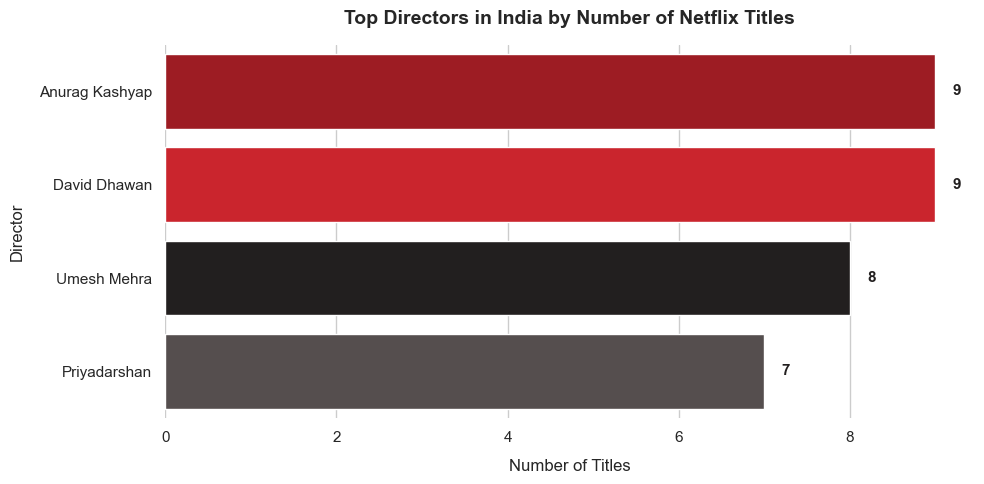

In [21]:
plt.figure(figsize=(10, 5))

# Filter out 'Unknown' to get the actual directors
real_top_directors = top_india_directors[top_india_directors.index != 'Unknown']

# Define a clean red-and-dark palette for the filmmakers
director_colors = ['#b20710', '#e50914', '#221f1f', '#564d4d']

# Create the horizontal bar plot
ax = sns.barplot(
    x=real_top_directors.values, 
    y=real_top_directors.index, 
    palette=director_colors,
    hue=real_top_directors.index,
    legend=False
)

# Titles and labels
plt.title('Top Directors in India by Number of Netflix Titles', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Titles', fontsize=12, labelpad=10)
plt.ylabel('Director', fontsize=12, labelpad=10)

# Add exact counts next to each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width + 0.2, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', color='#221f1f')

# Clean up chart borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

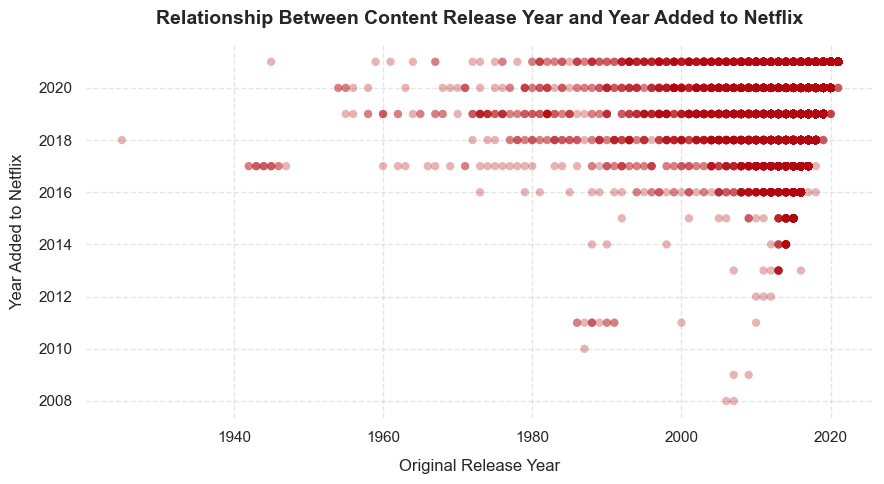

--- Statistical Summary ---
Pearson Correlation Coefficient: 0.1116


In [24]:
import numpy as np

# Create a clean scatter plot with a density layer to handle heavy overlapping data points
plt.figure(figsize=(9, 5))

# Use a jointplot or standard scatter with transparency (alpha) since there are thousands of rows
sns.scatterplot(
    data=df, 
    x='release_year', 
    y='year_added', 
    alpha=0.3, 
    color='#b20710',
    edgecolor='none'
)

# Titles and labels
plt.title('Relationship Between Content Release Year and Year Added to Netflix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Original Release Year', fontsize=12, labelpad=10)
plt.ylabel('Year Added to Netflix', fontsize=12, labelpad=10)

# Set grid lines for readability
plt.grid(visible=True, linestyle='--', alpha=0.5)

# Clean up chart borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Calculate the actual Pearson correlation coefficient to see the strength of the linear relationship
correlation = df['release_year'].corr(df['year_added'])
print(f"--- Statistical Summary ---")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

In [25]:
# Calculate the gap in years between the release and when it was added
df['acquisition_gap'] = df['year_added'] - df['release_year']

# Sort the dataset to find the titles with the largest gap
longest_gap = df[['title', 'type', 'release_year', 'year_added', 'acquisition_gap']].sort_values(by='acquisition_gap', ascending=False).head(5)

print("--- Top 5 Titles with the Longest Acquisition Gap ---")
print(longest_gap.to_string(index=False))

--- Top 5 Titles with the Longest Acquisition Gap ---
                              title    type  release_year  year_added  acquisition_gap
  Pioneers: First Women Filmmakers* TV Show          1925        2018               93
Five Came Back: The Reference Films TV Show          1945        2021               76
                     Prelude to War   Movie          1942        2017               75
               The Battle of Midway   Movie          1942        2017               75
    WWII: Report from the Aleutians   Movie          1943        2017               74


In [26]:
# Check for any remaining missing values across all columns
missing_summary = df.isnull().sum()

print("--- Missing Values Summary ---")
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values left!")
print("\n" + "="*50 + "\n")

# Display the definitive final structure and shape of your analyzed dataframe
print("--- Final Cleaned Dataset Shape ---")
print(f"Total Rows (Titles): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")
print("\n" + "="*50 + "\n")

# Show descriptive statistics for our numerical fields including the new gap metric
print("--- Descriptive Statistics for Numerical Fields ---")
print(df[['release_year', 'year_added', 'acquisition_gap']].describe().round(2))

--- Missing Values Summary ---
No missing values left!


--- Final Cleaned Dataset Shape ---
Total Rows (Titles): 8790
Total Columns (Features): 15


--- Descriptive Statistics for Numerical Fields ---
       release_year  year_added  acquisition_gap
count       8790.00     8790.00          8790.00
mean        2014.18     2018.87             4.69
std            8.83        1.57             8.79
min         1925.00     2008.00            -3.00
25%         2013.00     2018.00             0.00
50%         2017.00     2019.00             1.00
75%         2019.00     2020.00             5.00
max         2021.00     2021.00            93.00
